# 1. Project Setup

## Import libraries

In [1]:
import numpy as np
import pandas as pd
import os
import ast
import geopandas as gpd
from shapely import wkt
import contextily as ctx
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

np.random.seed(42) 

## Call API to download NYC Street Construction Permit Data from 2014 to 2024

Downloads NYC street construction permit data (2014-2024) from SODA2 API via CSV, combining two datasets (2013-2021 and 2022-present). 

**Process:**
- If `data/WIP_street_construction_permits.csv` exists (approximate 2GB in file size), loads from file
- Otherwise, call API to download and preprocessed to `df_cleaned`

Removes records with:
- Missing dates ('issuedworkstartdate', 'issuedworkenddate')
- Missing location ('wkt')
- Duplicate date-location combinations

Validates remaining data and converts dates to year-month format.

**WARNING: Initial download may take 20+ minutes**

In [2]:
from utils.helpers import SODA2_API_NYCDATA, clean_permit_data, validate_cleaned_data

# Street Construction Permits (2022-Present) https://data.cityofnewyork.us/Transportation/Street-Construction-Permits-2022-Present-/tqtj-sjs8/about_data 
api_url_2022_now = "https://data.cityofnewyork.us/resource/tqtj-sjs8.json" 

# Street Construction Permits (2013-2021) https://data.cityofnewyork.us/Transportation/Street-Construction-Permits-2013-2021-/c9sj-fmsg/about_data
api_url_2013_2021 = "https://data.cityofnewyork.us/resource/c9sj-fmsg.json" 

# Columns to retrieve
columns = [
    "permitnumber",
    "permittypeid",
    "permittypedesc",
    "permithousenumber",
    "onstreetname",
    "fromstreetname",
    "tostreetname",
    "permitlinearfeet",
    "issuedworkstartdate",
    "issuedworkenddate",
    "boroughname",
    "permitteename",
    "permitpurposecomments",
    "wkt"
]

# Parameters for 2014-2024 dataset
params = {
    "$limit": 10_000_000,
    "$where": "date_extract_y(issuedworkstartdate) IN (2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024)",
    "$select": ",".join(columns)
}

file_path = 'data/WIP_street_construction_permits.csv'

if os.path.exists(file_path):
    print(f" Use existing file: {file_path} as cleaned street construction permit data: 'df_cleaned'")
    df_cleaned = pd.read_csv(file_path, dtype={1: str,
                                               5: str}) # set columns 1 and 5 ('permitnumber', 'permitteename) as Str
    print(f"df_cleaned has shape of {df_cleaned.shape}")
    
else:
    print("Street construction data was not found. Downloading dataset...")
    
    # Download 2013-2021 data
    df_2013_2021 = SODA2_API_NYCDATA(api_url_2013_2021, params)
    print(f"Downloaded {len(df_2013_2021)} rows from 2013-2021 dataset") # Should have ~ 4.2 mil rows from 2013-2021 dataset

    # Download 2022-Present data
    df_2022_now = SODA2_API_NYCDATA(api_url_2022_now, params)
    print(f"Downloaded {len(df_2022_now)} rows from 2022-Present dataset") # Should have ~ 2.7 mil rows from 2022-Present dataset

    # Combine datasets
    df_combined = pd.concat([df_2013_2021, df_2022_now], ignore_index=True)
    print(f"Combined dataset shape: {df_combined.shape}")
    print(f"Date range: {df_combined['issuedworkstartdate'].min()} to {df_combined['issuedworkstartdate'].max()}")

    # remove rows with NaN in columns of 'issuedworkstartdate', 'issuedworkenddate', 'wkt' and remove duplicates
    # convert date columns to year-month date type
    df_cleaned = clean_permit_data(df_combined) 
    

    validate_cleaned_data(df_cleaned)

    print(f"Final dataset stored in variable: df_cleaned, with shape: {df_cleaned.shape}")

    ###################################
    # Uncomment below to save to csv
    ###################################

    # print("Saving cleaned data to CSV...")
    # df_cleaned.to_csv(file_path, index=False)
    # print(f"Data saved to '{file_path}'")


 Use existing file: data/WIP_street_construction_permits.csv as cleaned street construction permit data: 'df_cleaned'
df_cleaned has shape of (6865670, 14)


# 2. Data Processing

## Assign NYC Borough Community District (BoroCD) to Construction Permit

The native stree construction permit does not contain community board information for each record, so we have to assign and add BoroCD to the street construction permit data by spatially matching permit geometries with community district boundaries, either loading from existing CSV with community district data ('WIP_street_construction_permits_with_cd.csv') or processing 'df_cleaned' to have 'df_permit_cd'. 

**Process:**
- If `data/WIP_street_construction_permits_with_cd.csv` exists (approximate 2GB in file size), loads from file
- Otherwise, processes `df_cleaned` to create `df_permit_cd` with BoroCD assignments 
    - **WARNING**: Processing geospatial data and assigning BoroCD may take 20+ minutes

**BoroCD Format:**
Three-digit code where:
- First digit = borough (1=Manhattan, 2=Bronx, 3=Brooklyn, 4=Queens, 5=Staten Island)
- Last two digits = community district number within that borough

**Examples:**

| Borough CD             | Borough & District | Description |
| :----------------: | :------: | :----: |
| 101        |   Manhattan 01 | Tribeca, Seaport/Civic Center, Financial District, Battery Park City |
| 201           |   Bronx 01| Mott Haven, Port Morris, and Melrose |
| 301    |  Brooklyn 01 | Flushing Avenue, Williamsburg, Greenpoint, Northside, and Southside |
| 401  |  Queens 01| Astoria, Old Astoria, Long Island City, and others  |
| 501  |  Staten Island 01| Arlington, Castleton Corners, Clifton, Concord, and others |

*Full lookup table: `data/lookup_boroCD_community_board.csv`*

The `add_community_districts` function assigns NYC community district information to construction permit records through spatial analysis:

1. Validation: Verifies WKT geometry column exists and loads NYC community district boundary data
2. Geometry Parsing Converts WKT strings (EPSG:2263 coordinate system) into geometric objects and extracts metadata (type, point count)
3. Distance Calculation Computes length or perimeter of each geometry in feet
4. District Assignment 
   - Identifies community district(s) that intersect with each permit geometry
   - Prioritizes matching BoroCD with the permit's borough
   - Falls back to nearest district for geometries outside boundaries
5. Result Processing 
   - Determines primary (dominant) community district for each permit
   - Calculates percentage of geometry falling within each intersecting district

**WARNING: Processing geospatial data and assigning BoroCD may take 20+ minutes**

In [3]:
from utils.CD_conversion import add_community_districts

cd_file_path = 'data/WIP_street_construction_permits_with_cd.csv'

if os.path.exists(cd_file_path):
    print(f"Use existing file: {cd_file_path} as cleaned street construction permit data: 'df_permit_cd'")
    df_permit_cd = pd.read_csv(cd_file_path, dtype={1: str,
                                                    5: str}) # set columns 1 and 5 ('permitnumber', 'permitteename) as Str
    # Convert string representation of dict back to dict
    df_permit_cd['cd_wkt_dict'] = df_permit_cd['cd_wkt_dict'].apply(ast.literal_eval) 
    print(f"df_permit_cd has shape of {df_permit_cd.shape}")
    
else:
    print("Street construction with community board data was not found. Processing street data and append community board columns...")
    df_permit_cd = add_community_districts(df_cleaned, 'wkt', batch_size=10_000) #batch 5000 has 46 min runtime; 100_000 has 54 min runtime
    print(f"df_permit_cd has shape of {df_permit_cd.shape}")
    ###################################
    # Uncomment below to save to csv
    ###################################
    # print("Saving cleaned data to CSV...")
    # df_permit_cd.to_csv(cd_file_path, index=False)
    # print(f"Data saved to '{cd_file_path}'")


Use existing file: data/WIP_street_construction_permits_with_cd.csv as cleaned street construction permit data: 'df_permit_cd'
df_permit_cd has shape of (6865670, 17)


## Validation on assigned community board 

Displays permits with missing community district assignments. Since only two records cannot be assigned with BoroCD, we manually assigns community districts based on the 'wkt' geospatial information: 

- permitnumber: Q012018065A34 → primary_cd: 413
- permitnumber: X152023240A06 → primary_cd: 212

We also visually inspected the active construction counts with respect to each BoroCD from 2014 to 2024, and found out all the available records have been properly assigned. 

In [4]:
display(df_permit_cd[['permitnumber','onstreetname', 'boroughname','wkt', 'primary_cd' ]].loc[df_permit_cd['primary_cd'].isna()])
df_permit_cd.loc[df_permit_cd['permitnumber'] == 'Q012018065A34', 'primary_cd'] = 413 # manual lookup and assign community board
df_permit_cd.loc[df_permit_cd['permitnumber'] == 'X152023240A06', 'primary_cd'] = 212 # manual lookup and assign community board

df_permit_cd['primary_cd'] = df_permit_cd['primary_cd'].astype(str).str.replace(r'\.0$', '', regex=True)

print(f"The street construction permit counts in each borough: \n {df_permit_cd['boroughname'].value_counts()}")
print(f"The street construction permit counts in each community board: \n {df_permit_cd['primary_cd'].value_counts()}")

,permitnumber,onstreetname,boroughname,wkt,primary_cd
2827990,Q012018065A34,257 STREET,QUEENS,MULTIPOINT ((1065275.6852999926 204580.1979999...,NaN
6834898,X152023240A06,BOROUGH BOUNDARY,BRONX,MULTIPOINT ((1023900.8282999992 269486.3519999...,NaN


The street construction permit counts in each borough: 
 boroughname
BROOKLYN         2039407
MANHATTAN        1980176
QUEENS           1557751
BRONX             769388
STATEN ISLAND     518948
Name: count, dtype: int64
The street construction permit counts in each community board: 
 primary_cd
105    324522
301    243953
108    236395
104    206191
102    202116
        ...  
227       868
228       728
484       642
483       592
356       338
Name: count, Length: 71, dtype: int64


## Random samples to validate the assigned BoroCD

We also randomly selected 20 random permit records to validate the assigned BoroCD, and all of the sampled BoroCD are correctly assigned. The original data has 'wkt' columns consisting of geospatial information of each permit, and we extract the first coordinates to find out the location and compare it against the NYC official community board maps.  The validation consists of following steps:

**Validation Process:**

1. Extract Coordinates: Extract the coordinates of first point from 'wkt' at each sample (`get_first_coordinate` function)
2. Coordinate System: The coordinates are stored in Easting and Northing in New York Long Island State Plane (NY L-3104)
3. Convert to Lat/Long: Use NOAA NGS Coordinate Conversion and Transformation Tool (NCAT) to convert the NY L-3104 coordinate into latitude and longitude
    - NCAT: https://www.ngs.noaa.gov/NCAT/
    - Inputs for the coordinates converstion:
        - Convert/Transform from: 'Horizontal' 
        - Select the type of horizontal coordinate: 'SPC' 
        - Use Coordinates from 'wkt' (Easting, Northing) 
        - Units: 'US Survey Feet ' 
        - SPC Zone: 'NY L-3104' 
        - Select Submit 
        - Use output Latitude and Longitude (NAD83)in Google Maps to validate if the location is actually within the community district assigned

4. Verify Location: Compare the NYC's community board map to make sure the corresponding latitude and longitude are located into the assigned BoroCD ('primary_cd')
    - NYC Community Board Map: http://www.arcgis.com/apps/mapviewer/index.html?url=https://services5.arcgis.com/GfwWNkhOj9bNBqoJ/ArcGIS/rest/services/NYC_Community_Districts/FeatureServer/0&source=sd

In [5]:
from utils.CD_conversion import get_first_coordinate

sampled_permit = df_permit_cd[['permitnumber', 'boroughname', 'wkt', 'primary_cd']].sample(n=20, random_state=42)

sampled_permit[['easting', 'northing']] = sampled_permit['wkt'].apply(lambda x: pd.Series(get_first_coordinate(x)))
pd.set_option('display.float_format', '{:.4f}'.format)
display(sampled_permit[['permitnumber', 'northing', 'easting', 'primary_cd']])


,permitnumber,northing,easting,primary_cd
5147026,M012023132A58,200206.5127,987705.4427,103
6711001,X022022101A87,246655.1260,1006372.9914,204
6458002,S022024152A34,159513.7574,950164.4164,502
4213814,B012019091G28,186230.3272,1016068.6460,305
2494681,M162018319A21,205447.1385,983783.0916,102
1416177,M012017304A82,224869.8448,989763.6045,107
3973988,X022018263A28,249623.6073,1011147.4586,205
3558354,S012018116A48,160188.5592,936904.2892,502
5456024,M022024189A00,198557.4376,983087.5744,101
1161220,B162019305B08,173209.7334,981512.6926,307


# 3. Exploratory Data Analysis


## Top 10 Street construction permit type over the years

Creates a color palette representing noise levels from loud (red) to quiet (dark gray), maps permit type IDs to descriptions, and generates a stacked bar chart visualizing the top 10 NYC street construction permit types over time using the noise-inspired color scheme. Keyp findings include:

- **Pre-COVID Growth**: Permits increased approximately from 480K (2014) to 740K (2019)
- **COVID Impact**: Dropped to approximate 610K in 2020
- **Recovery**: Gradually rebounded to approximate 660K by 2024

The most common top 5 permit types remained consistent throughout the period:
- Equipment placement
- Refuse containers
- Sidewalk occupancy
- Roadway occupancy
- Major gas installation

The top 10 construction types take up approximately half of the all construction permits, which is significant compared to overall 200+ construction types.

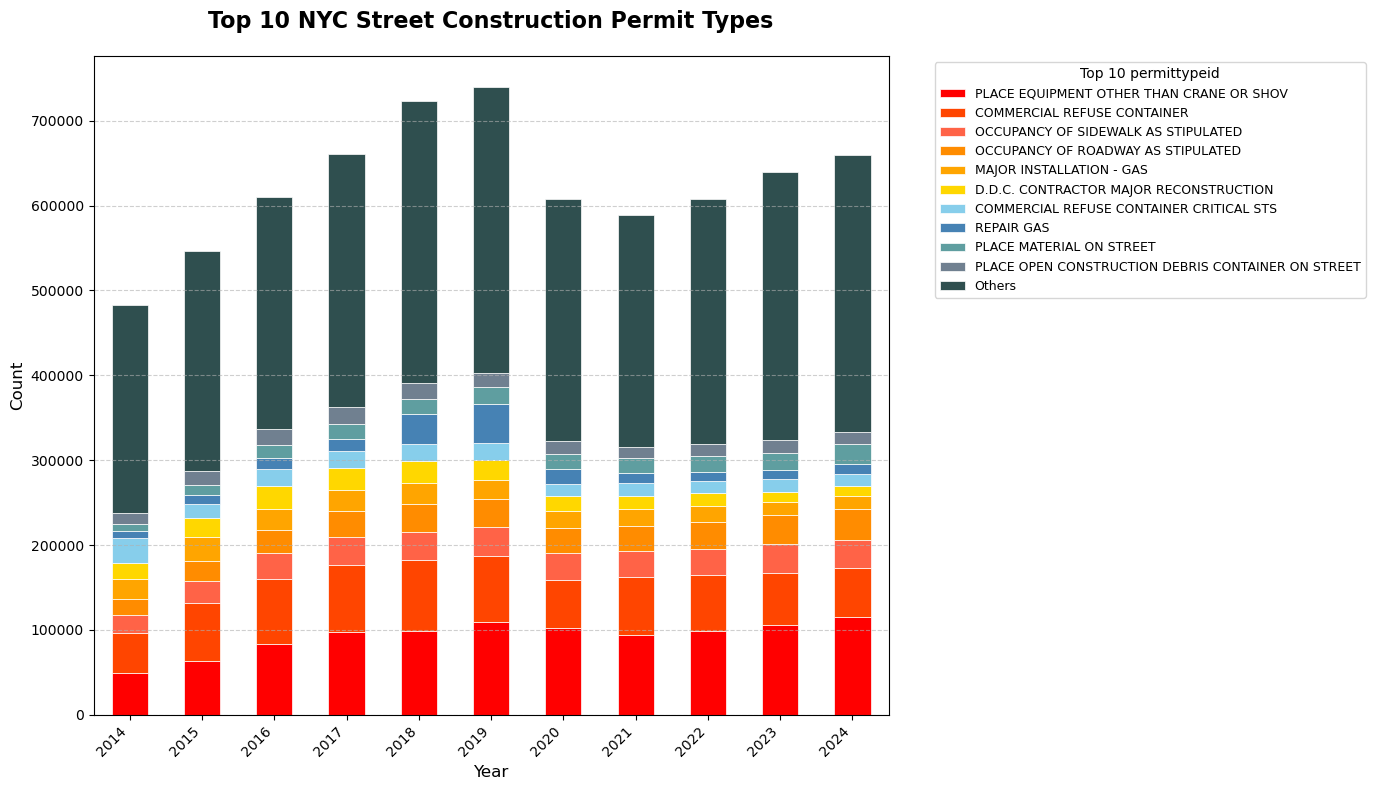

In [6]:
from utils.helpers import plot_stacked_bar

noise_colors = [
    '#FF0000',  # Loud red (sirens, alarms)
    '#FF4500',  # Orange red (construction)
    '#FF6347',  # Tomato (street noise)
    '#FF8C00',  # Dark orange (traffic)
    '#FFA500',  # Orange (horns)
    '#FFD700',  # Gold (transition)
    '#87CEEB',  # Sky blue (quieter)
    '#4682B4',  # Steel blue (calm)
    '#5F9EA0',  # Cadet blue (peaceful)
    '#708090',  # Slate gray (quiet)
    '#2F4F4F'   # Dark slate gray (silence)
    ]


top_n = 10

permit_type_dict = df_permit_cd[['permittypeid', 'permittypedesc']].drop_duplicates().set_index('permittypeid')['permittypedesc'].to_dict()

# Get top 10 permit types by count
top_permit_ids = df_permit_cd['permittypeid'].value_counts().head(top_n).index

top_permit = pd.DataFrame({
    'permittypeid': top_permit_ids,
    'permittypedesc': [permit_type_dict[pid] for pid in top_permit_ids],
    'count': [df_permit_cd['permittypeid'].value_counts()[pid] for pid in top_permit_ids]
})

fig, ax = plot_stacked_bar(df_permit_cd, 'issuedworkstartdate', 'permittypeid', 
                           title=f'Top {top_n} NYC Street Construction Permit Types', 
                           top_n=top_n, label_map=permit_type_dict, color_map=noise_colors)

In [7]:
print(f"There are {len(permit_type_dict)} types of street construction in total, and the top {top_n} types are:")
display(top_permit)

There are 212 types of street construction in total, and the top 10 types are:


,permittypeid,permittypedesc,count
0,0204,PLACE EQUIPMENT OTHER THAN CRANE OR SHOV,1017677
1,1600,COMMERCIAL REFUSE CONTAINER,742843
2,0215,OCCUPANCY OF SIDEWALK AS STIPULATED,335987
3,0211,OCCUPANCY OF ROADWAY AS STIPULATED,328846
4,0103,MAJOR INSTALLATION - GAS,236536
5,0158,D.D.C. CONTRACTOR MAJOR RECONSTRUCTION,217219
6,1601,COMMERCIAL REFUSE CONTAINER CRITICAL STS,198175
7,0122,REPAIR GAS,192166
8,0201,PLACE MATERIAL ON STREET,185907
9,0214,PLACE OPEN CONSTRUCTION DEBRIS CONTAINER ON ST...,177645


## Street permit counts over the years

In terms of construction permit counts by borough, below chart shows Brooklyn and Manhattan consistently have the higher permit counts, each accounting for roughly 126K to 235K permits annually. Queens has slightly less permit counts than Brooklyn and Manhattan, while Staten Island have notably lower construction activities. The 'COVID effect' seemed to affect each borough evenly with highest permit counts in 2019, significant dropped in 2020, and gradually recovered by 2024. 

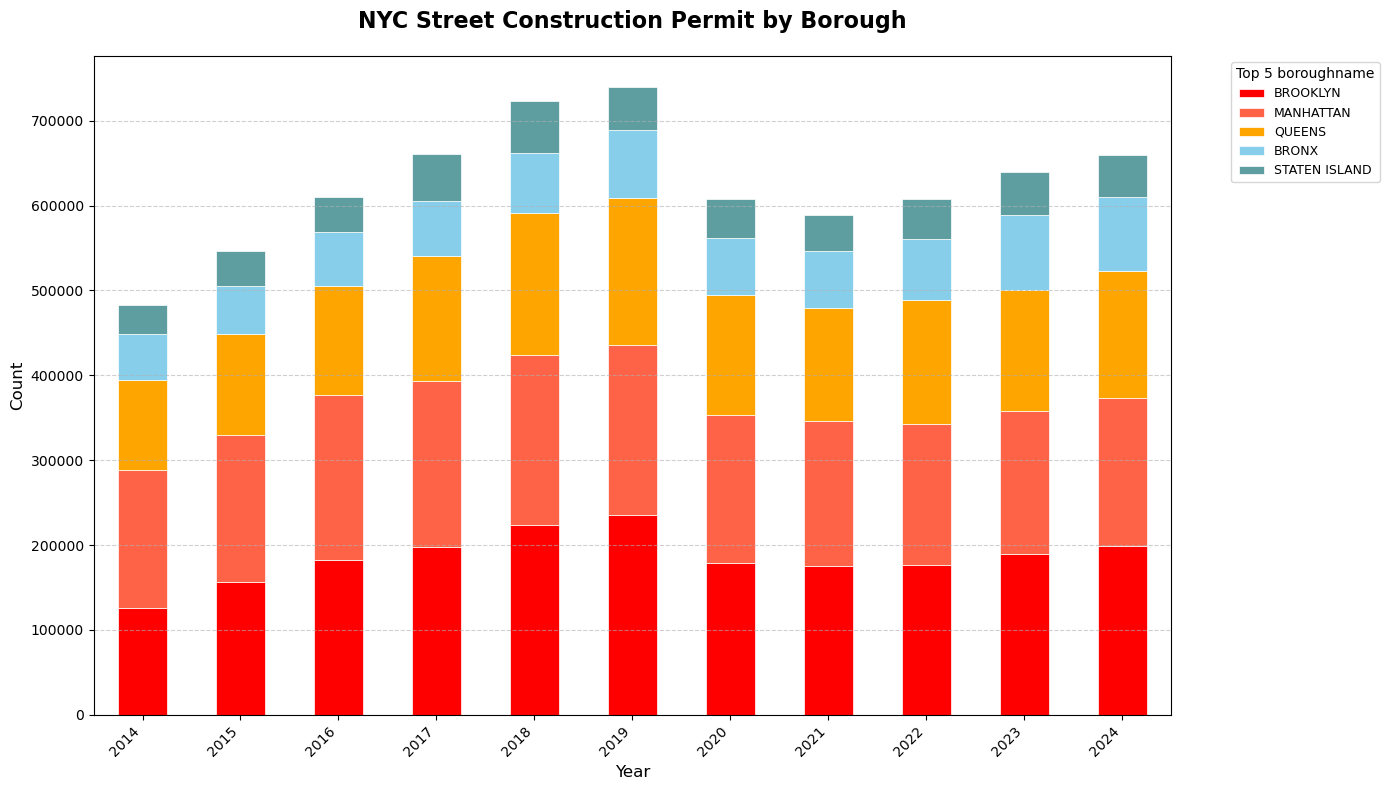

In [8]:
df_permit_cd['year'] = pd.to_datetime(df_permit_cd['issuedworkstartdate']).dt.year

borough_by_year = df_permit_cd.groupby(['year', 'boroughname']).size().unstack(fill_value=0)

borough_order = ['MANHATTAN', 'BRONX', 'BROOKLYN', 'QUEENS', 'STATEN ISLAND']

existing_boroughs = [b for b in borough_order if b in borough_by_year.columns]
borough_by_year = borough_by_year[existing_boroughs]

fig, ax = plot_stacked_bar(df_permit_cd, 'issuedworkstartdate', 'boroughname', 
                           title='NYC Street Construction Permit by Borough', color_map= noise_colors[::2])

In [9]:
print("Street construction permits by borough and year:")
display(borough_by_year)

Street construction permits by borough and year:


boroughname,MANHATTAN,BRONX,BROOKLYN,QUEENS,STATEN ISLAND
year,,,,,
2014,161863,55091,126303,105981,33849
2015,173354,56782,156014,119091,40663
2016,194415,62539,182308,129091,41401
2017,195798,65181,197285,147342,55021
2018,200001,70341,224095,167120,61478
2019,199815,79922,235615,173766,50462
2020,174018,66168,178954,142214,46704
2021,170897,66139,175195,133733,43409
2022,166488,71674,176239,146488,46784


In [10]:
display(borough_by_year)


boroughname,MANHATTAN,BRONX,BROOKLYN,QUEENS,STATEN ISLAND
year,,,,,
2014,161863,55091,126303,105981,33849
2015,173354,56782,156014,119091,40663
2016,194415,62539,182308,129091,41401
2017,195798,65181,197285,147342,55021
2018,200001,70341,224095,167120,61478
2019,199815,79922,235615,173766,50462
2020,174018,66168,178954,142214,46704
2021,170897,66139,175195,133733,43409
2022,166488,71674,176239,146488,46784


## Sampled street construction permit distribution map

We sampled 1 million random permits to generate a map visulazation by borough from converted coordinates, and the results appear to show the linear gridded street patterns as expected in the native permit dataset. In the below map, Manhattan (blue) shows higher density than other borough, especially in downtown neighborhoods. Staten Island (dark gray) shows the lowest dentiy, consistent with its lowest permit counts among the boroughs. 

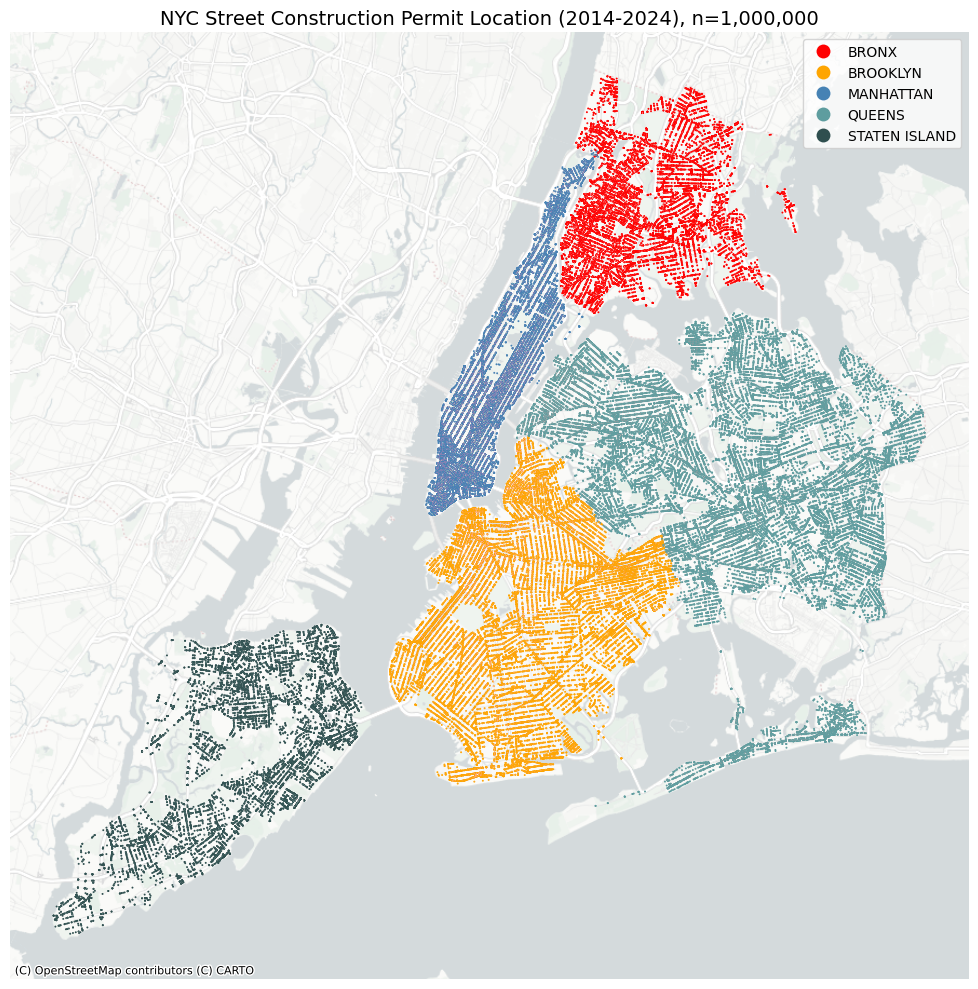

In [11]:

try:
    df_permit_cd['wkt'] = gpd.GeoSeries.from_wkt(df_permit_cd['wkt']) #loadin from csv requires conversion from str to shapely geometry type

except (TypeError, AttributeError):
    pass

gdf = gpd.GeoDataFrame(df_permit_cd[['wkt', 'boroughname']], geometry='wkt') 


# Set the original CRS from NAD83 / New York Long Island (EPSG:2263)
gdf = gdf.set_crs(epsg=2263)

# Project to Web Mercator (EPSG:3857) for basemap compatibility
gdf = gdf.to_crs(epsg=3857)

# Create figure
fig, ax = plt.subplots(figsize=(12, 10))

maps_indice = [0, 4, 7, 8, 10]
map_colors = [ noise_colors[i] for i in maps_indice]

cmap = LinearSegmentedColormap.from_list("noise_gradient", map_colors)

n_sample = 1_000_000
gdf_sample = gdf.sample(n=n_sample) 

# Plot the data colored by 'boroughname' column
gdf_sample.plot(ax=ax,  legend=True, column='boroughname',
        markersize=2,# alpha=0,
        edgecolor='white', linewidth=0.005, 
        cmap=cmap) 

# Add CartoDB PositronNoLabels basemap
ctx.add_basemap(ax, source=ctx.providers.CartoDB.PositronNoLabels)

ax.set_axis_off()
ax.set_title(f'NYC Street Construction Permit Location (2014-2024), n={n_sample:,}', fontsize=14)

plt.tight_layout()
plt.savefig('data/sampled_street_construction_location_map.png', dpi=300, bbox_inches='tight')
plt.show()


# 4. Explode Street Construction Permit to Active Construction Counts and Average Size (Linearage) per month per BoroCD

After a preliminary exploratory data analysis, we need to explode and street construction permit dataset so that this information can be used in the baseline NYC 311 Noise Complaint model. Specifically, we transform the permit dataset into two monthly metrics by community district:


1. **Active Construction Count**: Number of active permits per month (`calculate_monthly_active_work_counts`)
2. **Average Construction Size**: Mean linear feet of construction per month (`calculate_monthly_average_linearfeet`)


**Process:**
- If pre-computed files exist (`data/monthly_active_work_counts.csv`, `data/monthly_average_linearfeet.csv`), loads from CSV
- Otherwise, computes metrics from permit data
    - Output Format: Both DataFrames have months as rows and BoroCD as columns, with values representing either count or average size (linear feet).

**Example:** See `data/Construction_Permit_to_CD_Counts_Example.xlsx` for sample output structure

**WARNING: Computing these two metrics from permit data may take 10+ minutes**

In [12]:
from utils.Construction_to_311_Noise import calculate_monthly_active_work_counts, calculate_monthly_average_linearfeet


wc_file_path = 'data/monthly_active_work_counts.csv'
if os.path.exists(wc_file_path):
    print(f" Use existing file: {wc_file_path} as monthly active construction counts as 'active_work_counts_df'")
    active_work_counts_df = pd.read_csv(wc_file_path)
    
else:
    print("Monthly active construction data was not found. Calculating data...")
    active_work_counts_df = calculate_monthly_active_work_counts(df_permit_cd)

    print(f"Final dataset stored in variable: active_work_counts_df, with shape: {active_work_counts_df.shape}")

    ###################################
    # Uncomment below to save to csv
    ###################################
    # print("Saving data to CSV...")
    # active_work_counts_df.to_csv(wc_file_path, index=False)
    # print(f"Data saved to '{wc_file_path}'")

acf_file_path = 'data/monthly_average_linearfeet.csv'
if os.path.exists(acf_file_path):
    print(f" Use existing file: {acf_file_path} as average construction footage as 'avg_linearfeet_df'")
    avg_linearfeet_df = pd.read_csv(acf_file_path)
    
else:
    print("Average construction footage data was not found. Calculating data...")
    avg_linearfeet_df = calculate_monthly_average_linearfeet(df_permit_cd)

    print(f"Final dataset stored in variable: avg_linearfeet_df, with shape: {avg_linearfeet_df.shape}")

    ###################################
    # Uncomment below to save to csv
    ###################################
    print("Saving data to CSV...")
    avg_linearfeet_df.to_csv(acf_file_path, index=False)
    print(f"Data saved to '{acf_file_path}'")


 Use existing file: data/monthly_active_work_counts.csv as monthly active construction counts as 'active_work_counts_df'
 Use existing file: data/monthly_average_linearfeet.csv as average construction footage as 'avg_linearfeet_df'
